# Permutation Null test - Spatial $P_\mathrm{blue}$

## Purpose

Here we test the circularity of the generating mechanism, but performing a null test. We preserve CSS positions, galaxy apertures/annuli, footprint geometry, object counts, local-density field, and the current background estimator, while destroying the association between $P_{\rm blue}$ and spatial position.

## Null hypothesis

The observed association between local GC density and the galaxy-level $\Delta f_b$ statistic does not require any spatial association between GC colour/$P_{\rm blue}$ and position.

The permutation preserves:

- CSS sky positions and magnitudes;
- galaxy aperture and annulus geometry;
- spatial counts and local-density measurements;
- survey footprint/coverage;
- the magnitude-dependent $P_{\rm blue}$ distribution;
- the submitted background-correction procedure.

$P_{\rm blue}$ values are randomized among CSS positions within the same GMM magnitude bin.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict
from tqdm.auto import tqdm

import ast
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import rayleightest
from scipy.stats import binomtest, ks_2samp, chi2, spearmanr,  pearsonr, linregress
from shapely.geometry import Polygon, Point
import logging

from src.config import (
    Columns,
    BCG,
    AnalysisConfig,
    ClusterCenter,
)

RNG_SEED = 20260830
rng = np.random.default_rng(RNG_SEED)

N_PERM = 1000   # development run

%load_ext autoreload
%autoreload 2

In [69]:
# logging function

def setup_logging(verbose=False, name = "Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [70]:
# Set verbosity here:
name = "spatial_pblue_null"
setup_logging(verbose=True, name = name)   # or False

# testing logging
logger = logging.getLogger(name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 09:27:36.459 Debug messages are ON
Info messages are always shown
[WARNING] 09:27:36.461 Warnings also show up


# Initialization

## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [5]:
def prep_gal_shapes(gals_df: pd.DataFrame) -> pd.DataFrame:
    g = gals_df.copy()

    # Convert minor axis from arcmin -> arcsec when present
    # (Your 'galdim_minaxis' is arcmin per your note)
    g["minor_axis_arcsec"] = np.where(
        np.isfinite(g["galdim_minaxis"]),
        g["galdim_minaxis"].astype(float) * 60.0,
        np.nan
    )

    # Axis ratio q=b/a using available axes (ratio is robust to diameter vs semi-axis ambiguity)
    a = g["major_axis_arcsec"].astype(float)
    b = g["minor_axis_arcsec"].astype(float)

    q = b / a
    # Clip to sane range; if missing, default to circular
    g["q_axis"] = np.where(np.isfinite(q), np.clip(q, 0.2, 1.0), 1.0)

    # Clean PA; if missing, set 0 (ellipse aligned N-S; effect minimal for q~1)
    g["pa_deg"] = pd.to_numeric(g["galdim_angle"], errors="coerce").fillna(0.0)

    return g


In [6]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
    gals_df_from_csv = gals_df.copy()
    gals_df = prep_gal_shapes(gals_df)
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.tail(5)

[WARNING] 11:07:33.036 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src,minor_axis_arcsec,q_axis,pa_deg
169,NGC 4874,194.898789,27.959248,LIN,0.023910,12.71,13.7,0.990000,12.6472,11.7979,...,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i,135.64440,0.966099,63.0
170,NGC 4869,194.847328,27.911592,EmG,0.022879,13.52,14.9,1.379999,14.4290,13.6240,...,3.2,23.865957,NaN,NaN,NaN,1.230054,g-i,41.45118,0.834300,47.0
171,NGC 4889,195.033738,27.977025,EmG,0.021500,11.30,13.0,1.700000,12.3528,11.5017,...,4.8,110.525917,NaN,NaN,NaN,1.033334,g-i,109.01400,0.621500,75.0
172,SDSS J130042.56+280658.6,195.177360,28.116320,LSB,0.020701,18.24,NaN,NaN,17.6480,17.0110,...,3.2,33.052243,NaN,NaN,NaN,0.868321,g-i,19.49800,1.000000,0.0
173,Coma cluster,195.017071,27.977025,CLUSTER,0.021500,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0


In [7]:
# Test the load
gal1=['IC 4051','NGC 4883','NGC 4876']
for gal_i in gal1:
    gal_row = gals_df.loc[gals_df['name'] == gal_i].iloc[0]
    print(f"{gal_i}: mv={gal_row['mV_app']:4.2f} mag, MV={gal_row['MV_abs']:5.2f} mag")


IC 4051: mv=13.34 mag, MV=-21.66 mag
NGC 4883: mv=14.34 mag, MV=-20.66 mag
NGC 4876: mv=14.49 mag, MV=-20.51 mag


In [8]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [9]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [10]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]
data_bright = data.loc[data['mag_814']<=25.0].copy()  # take a cut of data where completeness is > ~90% 

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [11]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)
total_bright = len(data_bright)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Total bright (F814W ≤ 25.0 mag): ', total_bright)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Total bright (F814W ≤ 25.0 mag):  10304
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [12]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='str')

## Load and verify the metrics quantities

In [13]:
metrics_df = pd.read_csv(
    "../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"
)

PB_METRIC = "Delta_Pblue_mean_bgsub"
COLOR_METRIC = "Delta_mean_color_bgsub"

required = [
    "mean_color",
    "mean_color_bgsub",
    COLOR_METRIC,
    PB_METRIC,
]

for col in required:
    print(f"{col:30s}", col in metrics_df.columns)



mean_color                     True
mean_color_bgsub               True
Delta_mean_color_bgsub         True
Delta_Pblue_mean_bgsub         True


## Check environmental metrics and baseline


In [14]:
sub = metrics_df[
    ["Delta_Pblue_mean_bgsub",
     "gc_bg_voronoi_density_arcsec2_inv"]
].dropna()

rho_obs, p_obs = spearmanr(
    sub["Delta_Pblue_mean_bgsub"],
    sub["gc_bg_voronoi_density_arcsec2_inv"]
)

print(rho_obs, p_obs)

-0.4420041180507892 9.183121292985238e-06


In [15]:
RHO_OBS = rho_obs
P_OBS   = p_obs

# Add $P_\mathrm{blue}$ to CSS data

In [16]:
# import numpy as np
# from typing import Tuple, Optional, Callable

# def _normal_pdf(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
#     """Vectorized Normal PDF."""
#     x = np.asarray(x, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     sigma = np.asarray(sigma, dtype=float)
#     return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)

# # These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
# #
#     # gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#     #     (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
#     #     (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
#     #     (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
#     #     (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
#     # ),

# def compute_Pblue(
#     mag814: np.ndarray,
#     color: np.ndarray,
#     *,
#     bright_mag_cut: float = 23.0,
#     # mag-binned mixture model for >= bright_mag_cut
#     mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
#     # These are the 'recalibrated values'
#     gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#         (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
#         (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
#         (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
#         (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
#     ),
#     # faint handling
#     faint_mode: str = "extend",   # "extend" or "clamp"
#     faint_max_edge: float = 28.0, # used only if extend
#     # optional prior modifier (later): fb(R) model
#     # If provided, pass an array fb of shape (N,) OR provide fb_func(r) separately.
#     fb: Optional[np.ndarray] = None,
# ) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Compute P(blue | color, mag) under a mag-binned 2-Gaussian mixture.

#     Returns:
#       Pblue (N,) float array
#       mag_bin_id (N,) int array (bright regime -> -1)
#     """
#     mag814 = np.asarray(mag814, dtype=float)
#     color = np.asarray(color, dtype=float)
#     if mag814.shape != color.shape:
#         raise ValueError("mag814 and color must have the same shape.")

#     N = mag814.size
#     Pblue = np.full(N, np.nan, dtype=float)
#     mag_bin_id = np.full(N, -1, dtype=int)

#     # Bright regime: undefined for bimodality by construction
#     bright = mag814 < bright_mag_cut
#     mid_or_faint = ~bright

#     # Prepare edges/params with faint handling
#     edges = np.asarray(mag_edges, dtype=float)
#     if faint_mode not in ("extend", "clamp"):
#         raise ValueError('faint_mode must be either "extend" or "clamp".')
#     params = np.array(gmm_params, dtype=float)
#     nbins = edges.size - 1
#     if params.shape[0] != nbins:
#         raise ValueError("gmm_params length must match len(mag_edges)-1.")

#     if faint_mode == "extend":
#         if faint_max_edge <= edges[-1]:
#             raise ValueError("faint_max_edge must be > mag_edges[-1] when extend.")
#         edges = np.concatenate([edges, [float(faint_max_edge)]])
#         params = np.vstack([params, params[-1:]])
#         nbins = edges.size - 1

#     if np.any(mid_or_faint):
#         m = mag814[mid_or_faint]
#         c = color[mid_or_faint]

#         bin_id = np.digitize(m, edges) - 1
#         bin_id = np.clip(bin_id, 0, nbins - 1)

#         mu_b = params[bin_id, 0]
#         sg_b = params[bin_id, 1]
#         mu_r = params[bin_id, 2]
#         sg_r = params[bin_id, 3]
#         w_b  = params[bin_id, 4]

#         # Likelihood terms
#         pb = w_b * _normal_pdf(c, mu_b, sg_b)
#         pr = (1.0 - w_b) * _normal_pdf(c, mu_r, sg_r)

#         # Optional prior modifier (later): replace w_b -> fb*w_b and (1-w_b)->(1-fb)*(1-w_b)?
#         # For now, if fb is provided, treat it as a multiplicative reweighting of the mixture prior:
#         if fb is not None:
#             fb_arr = np.asarray(fb, dtype=float)
#             if fb_arr.shape != mag814.shape:
#                 raise ValueError("fb must have the same shape as mag814/color if provided.")
#             fb_sub = fb_arr[mid_or_faint]
#             pb = fb_sub * pb
#             pr = (1.0 - fb_sub) * pr

#         denom = pb + pr
#         # Safe division
#         p = np.divide(pb, denom, out=np.full_like(pb, np.nan), where=denom > 0)

#         Pblue[mid_or_faint] = p
#         mag_bin_id[mid_or_faint] = bin_id

#     return Pblue, mag_bin_id


In [17]:
# Add in blue probability (based on magnitude and color of GCs)
# NOTE: The compute_Pblue function was originally below, but moved above as needs executing before 
# running this cell.

from src.color_metrics import compute_Pblue

Pblue_all, mag_bin_id = compute_Pblue(
    mag814=data["mag_814"].values,
    color=data["color"].values
)

data = data.copy()
data["Pblue"] = Pblue_all


## Check columns

In [18]:
keywords = [
    "A_",
    "Area_"
]

for keyword in keywords:
    matches = [
        c for c in metrics_df
        if keyword.lower() in c.lower()
    ]

    print(f"\n{keyword}:")
    print(matches)




A_:
['A_ap_geom', 'A_bg_geom', 'A_ap_eff', 'A_bg_eff', 'A_ap_eff_over_geom', 'A_bg_eff_over_geom', 'alpha_eff', 'alpha_geom', 'pa_deg', 'Delta_median_color', 'Delta_median_color_bgsub', 'Delta_mean_color', 'Delta_mean_color_bgsub', 'Delta_Pblue_mean', 'Delta_Pblue_mean_bgsub', 'Delta_Pblue_mean_bgsub_geom']

Area_:
[]


# Build cut-down routines

In [19]:
perm_data = data.copy().reset_index(drop=True)
perm_data["_perm_idx"] = np.arange(len(perm_data), dtype=int)

pblue_orig = perm_data["Pblue"].to_numpy(dtype=float)

In [20]:

def select_gc_samples_for_galaxy(
    data,
    gal_row,
    cols,
    kRe_inner=8.0,
    kRe_outer=(12.0, 20.0),
):
    """
    Returns inner and annulus GC samples for one galaxy.
    """
    kRe = elliptical_radius_kRe(
        data[cols.gc_ra].values,
        data[cols.gc_dec].values,
        gal_row[cols.gal_ra],
        gal_row[cols.gal_dec],
        gal_row[cols.gal_Re_arcsec],
        gal_row["q_axis"],
        gal_row["pa_deg"],
    )

    data = data.copy()
    data["kRe"] = kRe

    inner = data[kRe <= kRe_inner]
    ann = data[(kRe > kRe_outer[0]) & (kRe <= kRe_outer[1])]

    return inner, ann

def elliptical_radius_kRe(
    gc_ra, gc_dec,
    gal_ra, gal_dec,
    Re_arcsec,
    q_axis,
    pa_deg,
):
    """
    Compute elliptical radius in units of Re for each GC relative to a galaxy.
    PA assumed East of North (SIMBAD convention).
    """
    # SkyCoord objects
    gc = SkyCoord(gc_ra * u.deg, gc_dec * u.deg)
    gal = SkyCoord(gal_ra * u.deg, gal_dec * u.deg)

    # Tangent-plane offsets (arcsec)
    dra = (gc.ra - gal.ra).to(u.arcsec).value * np.cos(gal.dec.to(u.rad).value)
    ddec = (gc.dec - gal.dec).to(u.arcsec).value

    # Rotate into galaxy frame
    pa = np.deg2rad(pa_deg)
    x =  dra * np.cos(pa) + ddec * np.sin(pa)
    y = -dra * np.sin(pa) + ddec * np.cos(pa)

    # Elliptical radius (arcsec)
    r_ell = np.sqrt(x**2 + (y / q_axis)**2)

    # Return in units of Re
    return r_ell / Re_arcsec

## Build the membership cache once

In [21]:
@dataclass
class Columns:
    # galaxy table columns
    gal_id: str = "name"
    gal_ra: str = "ra"
    gal_dec: str = "dec"
    gal_Re_arcsec: str = "Re_best_arcsec"
    gal_MV: str = "MV_abs"

    # GC table columns
    gc_ra: str = "x_wcs"
    gc_dec: str = "y_wcs"
    gc_color: str = "color"           # e.g., F475W-F814W
    gc_mag: Optional[str] = "mag_814"  # optional
    gc_host: Optional[str] = "gal_id"  # if we already have assignment

@dataclass
class AnalysisConfig:
    aperture_Re: float = 8.0
    # optional background annulus for "local GC density"
    bg_annulus_inner_Re: float = 12.0
    bg_annulus_outer_Re: float = 20.0

    # bootstrap
    n_boot: int = 300
    min_gc_for_gmm: int = 30  # below this, we can fall back to median-only
    min_gc_for_Pblue: int = 10
    # baseline fit
    huber_eps: float = 1.35   # robust regression tuning


In [22]:
galaxy_cache = {}

cols = Columns
cfg = AnalysisConfig

for _, gal in tqdm(
    gals_df.iterrows(),
    total=len(gals_df),
    desc="Caching aperture membership"
):
    inner, ann = select_gc_samples_for_galaxy(
        perm_data,
        gal,
        cols,
        kRe_inner=cfg.aperture_Re,
        kRe_outer=(
            cfg.bg_annulus_inner_Re,
            cfg.bg_annulus_outer_Re,
        ),
    )

    # Use EXACTLY the same eligibility mask as the current
    # Pblue calculation in compute_metrics_for_galaxy.
    inner_mask = np.isfinite(inner["color"].to_numpy(dtype=float)) & np.isfinite(inner["Pblue"].to_numpy(dtype=float))
    ann_mask = np.isfinite(ann["color"].to_numpy(dtype=float)) & np.isfinite(ann["Pblue"].to_numpy(dtype=float))

    inner_idx = inner.loc[inner_mask, "_perm_idx"].to_numpy(dtype=int)
    ann_idx   = ann.loc[ann_mask, "_perm_idx"].to_numpy(dtype=int)

    gal_id = gal[cols.gal_id]

    galaxy_cache[gal_id] = {
        "inner_idx": inner_idx,
        "ann_idx": ann_idx,
    }  


Caching aperture membership:   0%|          | 0/174 [00:00<?, ?it/s]

## Pull fixed baseline metrics

In [23]:
fixed_metrics = (
    metrics_df
    .set_index(cols.gal_id)
)


In [24]:
science_ids = fixed_metrics.index[
    np.isfinite(fixed_metrics["Delta_Pblue_mean_bgsub"])
]
len(science_ids)

93

In [25]:
fixed_metrics["r_bg"] = (
    fixed_metrics["alpha_eff"]
    * fixed_metrics["N_annulus_Pblue"]
    / fixed_metrics["N_inner_Pblue"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_14898/3521669378.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fixed_metrics["r_bg"] = (


## Build/test unshuffled fast reconstruction

Before permutations, we should test only the background-subtracted values

In [26]:
from src.color_metrics import background_correct_scalar, bootstrap_Pblue_mean

rows = []

for gal_id in science_ids:

    cache = galaxy_cache[gal_id]

    inner_idx = cache["inner_idx"]
    ann_idx   = cache["ann_idx"]

    inner_p = pblue_orig[inner_idx]
    ann_p   = pblue_orig[ann_idx]

    n_in_p = len(inner_p)
    n_bg_p = len(ann_p)

    # Exact central statistic used in submitted pipeline
    p_med, _ = bootstrap_Pblue_mean(
        inner_p,
        cfg.n_boot,
        seed=0,
    )

    ann_mean = float(np.mean(ann_p))

    # Use the same effective areas as the original calculation
    area_inner = fixed_metrics.loc[gal_id, "A_ap_eff"]
    area_ann   = fixed_metrics.loc[gal_id, "A_bg_eff"]

    p_bgsub = background_correct_scalar(
        p_med,
        ann_mean,
        n_in_p,
        n_bg_p,
        area_inner,
        area_ann,
    )

    rows.append({
        cols.gal_id: gal_id,
        "Pblue_mean_fast": p_med,
        "Pblue_ann_fast": ann_mean,
        "Pblue_bgsub_fast": p_bgsub,
    })

fast_df = (
    pd.DataFrame(rows)
    .set_index(cols.gal_id)
)

and test this against the saved values...

In [27]:
checks = pd.DataFrame({
    "mean_diff": (
        fast_df["Pblue_mean_fast"]
        - fixed_metrics.loc[science_ids, "Pblue_mean"]
    ),
    "ann_diff": (
        fast_df["Pblue_ann_fast"]
        - fixed_metrics.loc[science_ids, "Pblue_mean_annulus"]
    ),
    "bgsub_diff": (
        fast_df["Pblue_bgsub_fast"]
        - fixed_metrics.loc[science_ids, "Pblue_mean_bgsub"]
    ),
})

print(checks.abs().describe())

          mean_diff      ann_diff    bgsub_diff
count  9.300000e+01  9.300000e+01  9.300000e+01
mean   6.565835e-18  5.968941e-19  5.043755e-17
std    1.802387e-17  5.756238e-18  4.892468e-17
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00  6.938894e-18
50%    0.000000e+00  0.000000e+00  5.551115e-17
75%    0.000000e+00  0.000000e+00  5.551115e-17
max    5.551115e-17  5.551115e-17  2.220446e-16


## Fast-path validated

The cached aperture/annulus implementation reproduces the galaxy-level
statistics from the full recalibrated pipeline to machine precision.

Maximum absolute differences:

- inner bootstrap $P_{\rm blue}$ mean: $5.6\times10^{-17}$
- annular mean $P_{\rm blue}$: $5.6\times10^{-17}$
- background-corrected $P_{\rm blue}$: $2.2\times10^{-16}$

The fast implementation can therefore be used for the permutation
experiment without rerunning the full galaxy-metric pipeline.

# Assign (and check) $P_\mathrm{blue}$ `mag_bin_id`'s

In [28]:
from src.color_metrics import compute_Pblue

mag814 = perm_data[cols.gc_mag].to_numpy(dtype=float)
color  = perm_data[cols.gc_color].to_numpy(dtype=float)

pblue_check, mag_bin_id = compute_Pblue(
    mag814,
    color,
)

In [29]:
mask = np.isfinite(pblue_orig) & np.isfinite(pblue_check)

diff = np.abs(
    pblue_orig[mask] - pblue_check[mask]
)

print(f"N compared = {mask.sum()}")
print(f"max |ΔPblue| = {diff.max():.3e}")

print(
    "NaN pattern identical:",
    np.array_equal(
        np.isnan(pblue_orig),
        np.isnan(pblue_check)
    )
)


N compared = 21834
max |ΔPblue| = 0.000e+00
NaN pattern identical: True


In [30]:
finite = np.isfinite(pblue_orig)

for b in np.unique(mag_bin_id[finite]):

    m = finite & (mag_bin_id == b)

    print(
        f"bin {b}: "
        f"N={m.sum():5d}, "
        f"mag={mag814[m].min():.3f}–{mag814[m].max():.3f}"
    )


bin 0: N= 2494, mag=23.001–24.000
bin 1: N= 7017, mag=24.000–25.000
bin 2: N= 9635, mag=25.000–26.000
bin 3: N= 2514, mag=26.000–26.998
bin 4: N=  174, mag=27.002–29.073


# Implement 1 permutation

## time the bootstrap helper

Gauge the time for the helper, so we can optimize if necessary


In [31]:
import time

t0 = time.perf_counter()

for gal_id in science_ids:
    idx = galaxy_cache[gal_id]["inner_idx"]
    bootstrap_Pblue_mean(
        pblue_orig[idx],
        cfg.n_boot,
        seed=0,
    )

dt = time.perf_counter() - t0

print(f"93 galaxy bootstraps: {dt:.3f} s")
print(f"Estimated 1000 permutations: {dt*1000/60:.1f} min")


93 galaxy bootstraps: 0.634 s
Estimated 1000 permutations: 10.6 min


## Shuffle $P_{\rm blue}$ while preserving magnitude structure


In [41]:
def permute_pblue_within_mag_bins(
    pblue_orig,
    mag814,
    rng,
):
    """
    Permute finite Pblue values among spatial positions within
    magnitude strata.

    Bright objects with undefined Pblue remain undefined.
    """
    p = np.asarray(pblue_orig, dtype=float)
    mag = np.asarray(mag814, dtype=float)

    p_perm = p.copy()

    # Preserve the empirical magnitude dependence.
    bins = [
        (23.0, 24.0),
        (24.0, 25.0),
        (25.0, 26.0),
        (26.0, 27.0),
        (27.0, np.inf),
    ]

    assigned = np.zeros(len(p), dtype=bool)

    for lo, hi in bins:
        mask = (
            np.isfinite(p)
            & np.isfinite(mag)
            & (mag >= lo)
            & (mag < hi)
        )

        idx = np.flatnonzero(mask)

        if len(idx) > 1:
            p_perm[idx] = rng.permutation(p[idx])

        assigned[idx] = True

    # Fail loudly if some finite Pblue values weren't covered.
    unassigned = np.isfinite(p) & ~assigned

    if np.any(unassigned):
        vals = mag[unassigned]
        raise ValueError(
            f"{unassigned.sum()} finite Pblue values were not assigned "
            f"to a permutation bin. Magnitude range: "
            f"{np.nanmin(vals):.3f}–{np.nanmax(vals):.3f}"
        )

    return p_perm

In [33]:
def permute_pblue_within_gmm_bins(
    pblue,
    mag_bin_id,
    rng,
):
    pblue = np.asarray(pblue, dtype=float)
    mag_bin_id = np.asarray(mag_bin_id, dtype=int)

    p_perm = pblue.copy()

    finite = np.isfinite(pblue)

    for b in np.unique(mag_bin_id[finite]):

        idx = np.flatnonzero(
            finite & (mag_bin_id == b)
        )

        if len(idx) > 1:
            p_perm[idx] = rng.permutation(pblue[idx])

    return p_perm


## Pass any $P_{\rm blue}$ assignment through the fast galaxy calculation

In [34]:
def fast_metrics_for_assignment(
    pblue,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cfg,
):
    """
    Calculate galaxy-level Pblue metrics for one assignment.

    Returns
    -------
    p_inner_raw : ndarray
        Arithmetic mean Pblue in the inner aperture.

    p_annulus : ndarray
        Arithmetic mean Pblue in the background annulus.

    p_bgsub : ndarray
        Submitted background-corrected Pblue statistic, using the
        bootstrap central value for the inner aperture.
    """

    p_inner_raw_values = []
    p_annulus_values = []
    p_bgsub_values = []

    for gal_id in science_ids:

        cache = galaxy_cache[gal_id]

        inner_p = pblue[cache["inner_idx"]]
        ann_p   = pblue[cache["ann_idx"]]

        n_in = len(inner_p)
        n_bg = len(ann_p)

        # Raw inner diagnostic
        p_inner_raw = float(np.mean(inner_p))

        # Submitted estimator uses bootstrap central value
        p_med, _ = bootstrap_Pblue_mean(
            inner_p,
            cfg.n_boot,
            seed=0,
        )

        # Annulus uses ordinary arithmetic mean
        p_annulus = float(np.mean(ann_p))

        p_bgsub = background_correct_scalar(
            p_med,
            p_annulus,
            n_in,
            n_bg,
            fixed_metrics.loc[gal_id, "A_ap_eff"],
            fixed_metrics.loc[gal_id, "A_bg_eff"],
        )

        p_inner_raw_values.append(p_inner_raw)
        p_annulus_values.append(p_annulus)
        p_bgsub_values.append(p_bgsub)

    return (
        np.asarray(p_inner_raw_values),
        np.asarray(p_annulus_values),
        np.asarray(p_bgsub_values),
    )

## Refit the Huber relation and calculate the null statistic

In [35]:
from src.color_metrics import fit_baseline_huber

def evaluate_pblue_assignment(
    pblue,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
    density_col="gc_bg_voronoi_density_arcsec2_inv",
):
    """
    Calculate four density correlations for one Pblue assignment:

      1. inner raw Pblue
      2. annulus Pblue
      3. background-subtracted Pblue
      4. MV-residualized background-subtracted Pblue
    """

    p_inner, p_annulus, p_bgsub = fast_metrics_for_assignment(
        pblue,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cfg,
    )

    MV = (
        fixed_metrics
        .loc[science_ids, cols.gal_MV]
        .to_numpy(dtype=float)
    )

    density = (
        fixed_metrics
        .loc[science_ids, density_col]
        .to_numpy(dtype=float)
    )

    # Refit MV baseline for this realization
    _, yhat = fit_baseline_huber(
        MV,
        p_bgsub,
        eps=cfg.huber_eps,
    )

    delta = p_bgsub - yhat

    def get_spearman(y):
        ok = np.isfinite(y) & np.isfinite(density)

        rho, pval = spearmanr(
            y[ok],
            density[ok],
        )

        return rho, pval, int(ok.sum())

    rho_inner, p_inner_rho, n_inner = get_spearman(p_inner)
    rho_ann,   p_ann_rho,   n_ann   = get_spearman(p_annulus)
    rho_bg,    p_bg_rho,    n_bg    = get_spearman(p_bgsub)
    rho_delta, p_delta_rho, n_delta = get_spearman(delta)

    return {
        # Correlation statistics
        "rho_inner": rho_inner,
        "p_inner": p_inner_rho,
        "N_inner": n_inner,

        "rho_annulus": rho_ann,
        "p_annulus": p_ann_rho,
        "N_annulus": n_ann,

        "rho_bgsub": rho_bg,
        "p_bgsub": p_bg_rho,
        "N_bgsub": n_bg,

        "rho_delta": rho_delta,
        "p_delta": p_delta_rho,
        "N_delta": n_delta,

        # Galaxy-level arrays, useful for diagnostics
        "Pblue_mean_inner_raw": p_inner,
        "Pblue_mean_annulus": p_annulus,
        "Pblue_mean_bgsub": p_bgsub,
        "Delta_Pblue_mean_bgsub": delta,
    }

# First test - Unshuffled

In [36]:
test_orig = evaluate_pblue_assignment(
    pblue_orig,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
)

for key in [
    "rho_inner",
    "rho_annulus",
    "rho_bgsub",
    "rho_delta",
]:
    print(f"{key:12s}: {test_orig[key]:+.4f}")


rho_inner   : -0.2823
rho_annulus : -0.6167
rho_bgsub   : -0.4084
rho_delta   : -0.4420


# Test 2 - One shuffle

In [67]:
rng = np.random.default_rng(20260830)

mag814 = perm_data[cols.gc_mag].to_numpy(dtype=float)

pblue_perm = permute_pblue_within_mag_bins(
    pblue_orig,
    mag814,
    rng,
)

test_perm = evaluate_pblue_assignment(
    pblue_perm,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
)

pairs = [
    ("Inner",          "rho_inner",   "p_inner"),
    ("Annulus",        "rho_annulus", "p_annulus"),
    ("Bg-subtracted",  "rho_bgsub",   "p_bgsub"),
    ("Delta f_b",      "rho_delta",   "p_delta"),
]

for label, rho_key, p_key in pairs:
    print(
        f"{label:15s}: "
        f"rho={test_perm[rho_key]:+.4f}  "
        f"p={test_perm[p_key]:.3g}"
    )


Inner          : rho=-0.1595  p=0.127
Annulus        : rho=-0.2618  p=0.0112
Bg-subtracted  : rho=-0.3733  p=0.000229
Delta f_b      : rho=-0.4149  p=3.54e-05


In [38]:
faint = (
    np.isfinite(pblue_orig)
    & np.isfinite(mag814)
    & (mag814 >= 28)
)

pd.DataFrame({
    "mag814": mag814[faint],
    "Pblue": pblue_orig[faint],
}).sort_values("mag814")

,mag814,Pblue
5,28.096572,0.840516
0,28.116236,0.005995
4,28.186531,0.742409
1,28.270369,0.724962
3,28.551979,0.839998
2,28.644614,0.711599
6,29.072730,0.001076


# One shuffle - test 2 (using recreated `mag_bin_id`'s)

In [47]:
rng = np.random.default_rng(20260830)

pblue_perm = permute_pblue_within_gmm_bins(
    pblue_orig,
    mag_bin_id,
    rng,
)

# Sanity checks
print(
    "Finite Pblue:",
    np.isfinite(pblue_orig).sum(),
    np.isfinite(pblue_perm).sum(),
)

print(
    "Multiset preserved:",
    np.allclose(
        np.sort(pblue_orig[np.isfinite(pblue_orig)]),
        np.sort(pblue_perm[np.isfinite(pblue_perm)]),
    )
)

test_perm = evaluate_pblue_assignment(
    pblue_perm,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
)

pairs = [
    ("Inner",          "rho_inner",   "p_inner"),
    ("Annulus",        "rho_annulus", "p_annulus"),
    ("Bg-subtracted",  "rho_bgsub",   "p_bgsub"),
    ("Delta f_b",      "rho_delta",   "p_delta"),
]

for label, rho_key, p_key in pairs:
    print(
        f"{label:15s}: "
        f"rho={test_perm[rho_key]:+.4f}  "
        f"p={test_perm[p_key]:.3g}"
    )

Finite Pblue: 21834 21834
Multiset preserved: True
Inner          : rho=-0.1595  p=0.127
Annulus        : rho=-0.2618  p=0.0112
Bg-subtracted  : rho=-0.3733  p=0.000229
Delta f_b      : rho=-0.4149  p=3.54e-05


# Test 3 - development ensemble of 10

In [52]:
pairs = [
    ("Inner",     "rho_inner"),
    ("Annulus",   "rho_annulus"),
    ("Bg-sub",    "rho_bgsub"),
    ("Delta f_b", "rho_delta"),
]

rng = np.random.default_rng(20260830)

rows = []

for i in range(10):

    pblue_perm = permute_pblue_within_gmm_bins(
        pblue_orig,
        mag_bin_id,
        rng,
    )

    result = evaluate_pblue_assignment(
        pblue_perm,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cols,
        cfg,
    )

    rows.append({
        "iteration": i + 1,
        "rho_inner": result["rho_inner"],
        "rho_annulus": result["rho_annulus"],
        "rho_bgsub": result["rho_bgsub"],
        "rho_delta": result["rho_delta"],
    })

    print(
        f"{i+1:3d}: "
        + "  ".join(
            f"{label}={result[key]:+.4f}"
            for label, key in pairs
        )
    )

rho_perm_10 = pd.DataFrame(rows)

for col in [
    "rho_inner",
    "rho_annulus",
    "rho_bgsub",
    "rho_delta",
]:
    vals = rho_perm_10[col]

    print(
        f"{col:12s}: "
        f"mean={vals.mean():+.4f}  "
        f"median={vals.median():+.4f}  "
        f"min={vals.min():+.4f}  "
        f"max={vals.max():+.4f}"
    )

  1: Inner=-0.1595  Annulus=-0.2618  Bg-sub=-0.3733  Delta f_b=-0.4149
  2: Inner=-0.1735  Annulus=-0.0427  Bg-sub=-0.3685  Delta f_b=-0.4232
  3: Inner=+0.1178  Annulus=-0.1015  Bg-sub=-0.3607  Delta f_b=-0.4060
  4: Inner=-0.0111  Annulus=-0.0089  Bg-sub=-0.3469  Delta f_b=-0.4049
  5: Inner=-0.2639  Annulus=+0.0477  Bg-sub=-0.4089  Delta f_b=-0.4572
  6: Inner=-0.2116  Annulus=-0.1285  Bg-sub=-0.3671  Delta f_b=-0.4228
  7: Inner=-0.1505  Annulus=+0.0784  Bg-sub=-0.3961  Delta f_b=-0.4380
  8: Inner=-0.0190  Annulus=-0.0328  Bg-sub=-0.4002  Delta f_b=-0.4716
  9: Inner=+0.0617  Annulus=-0.0896  Bg-sub=-0.3350  Delta f_b=-0.3775
 10: Inner=-0.0189  Annulus=-0.0760  Bg-sub=-0.3507  Delta f_b=-0.3981
rho_inner   : mean=-0.0829  median=-0.0848  min=-0.2639  max=+0.1178
rho_annulus : mean=-0.0616  median=-0.0593  min=-0.2618  max=+0.0784
rho_bgsub   : mean=-0.3707  median=-0.3678  min=-0.4089  max=-0.3350
rho_delta   : mean=-0.4214  median=-0.4188  min=-0.4716  max=-0.3775


# Test 4 - 100 permutations

Include TQDM monitor

In [54]:
from tqdm.auto import tqdm

N_PERM = 100
rng = np.random.default_rng(20260830)

rows = []

for i in tqdm(range(N_PERM), desc="Permutations"):

    pblue_perm = permute_pblue_within_gmm_bins(
        pblue_orig,
        mag_bin_id,
        rng,
    )

    result = evaluate_pblue_assignment(
        pblue_perm,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cols,
        cfg,
    )

    rows.append({
        "iteration": i + 1,
        "rho_inner": result["rho_inner"],
        "rho_annulus": result["rho_annulus"],
        "rho_bgsub": result["rho_bgsub"],
        "rho_delta": result["rho_delta"],
    })
    
null_df = pd.DataFrame(rows)

for col in [
    "rho_inner",
    "rho_annulus",
    "rho_bgsub",
    "rho_delta",
]:
    vals = null_df[col]

    print(
        f"{col:12s}: "
        f"mean={vals.mean():+.4f}  "
        f"median={vals.median():+.4f}  "
        f"std={vals.std():.4f}  "
        f"range={vals.min():+.4f} to {vals.max():+.4f}"
    )

Permutations:   0%|          | 0/100 [00:00<?, ?it/s]

rho_inner   : mean=-0.0831  median=-0.0730  std=0.0998  range=-0.3915 to +0.1178
rho_annulus : mean=-0.1235  median=-0.1184  std=0.1199  range=-0.4222 to +0.1512
rho_bgsub   : mean=-0.3658  median=-0.3621  std=0.0233  range=-0.4225 to -0.3097
rho_delta   : mean=-0.4164  median=-0.4143  std=0.0260  range=-0.4722 to -0.3599


In [55]:
rho_null = null_df["rho_delta"]

print(f"N perm       = {len(rho_null)}")
print(f"mean         = {np.mean(rho_null):+.4f}")
print(f"median       = {np.median(rho_null):+.4f}")
print(f"std          = {np.std(rho_null, ddof=1):.4f}")
print(f"16–84%       = {np.percentile(rho_null, [16,84])}")
print(f"2.5–97.5%    = {np.percentile(rho_null, [2.5,97.5])}")

n_extreme = np.sum(rho_null <= RHO_OBS)

p_emp = (n_extreme + 1) / (len(rho_null) + 1)

print(f"N <= observed = {n_extreme}")
print(f"Empirical p    = {p_emp:.4f}")


N perm       = 100
mean         = -0.4164
median       = -0.4143
std          = 0.0260
16–84%       = [-0.44335054 -0.39162245]
2.5–97.5%    = [-0.46662514 -0.37177345]
N <= observed = 17
Empirical p    = 0.1782


In [56]:
z_obs = (
    RHO_OBS - np.mean(rho_null)
) / np.std(rho_null, ddof=1)

print(f"Observed offset from null mean = {z_obs:+.2f} sigma")


Observed offset from null mean = -0.99 sigma


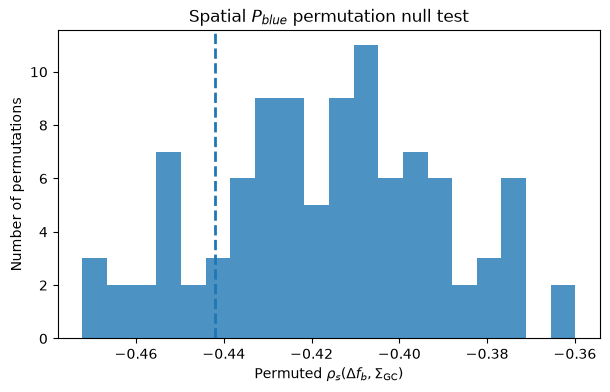

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(rho_null, bins=20, alpha=0.8)
ax.axvline(RHO_OBS, linestyle="--", linewidth=2)

ax.set_xlabel(r"Permuted $\rho_s(\Delta f_b,\Sigma_{\rm GC})$")
ax.set_ylabel("Number of permutations")
ax.set_title("Spatial $P_{blue}$ permutation null test")

plt.show()


In [58]:
from tqdm.auto import tqdm

N_PERM = 1000
rng = np.random.default_rng(20260830)

rows = []

for i in tqdm(range(N_PERM), desc="Permutations"):

    pblue_perm = permute_pblue_within_gmm_bins(
        pblue_orig,
        mag_bin_id,
        rng,
    )

    result = evaluate_pblue_assignment(
        pblue_perm,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cols,
        cfg,
    )

    rows.append({
        "iteration": i,
        "rho_inner": result["rho_inner"],
        "rho_annulus": result["rho_annulus"],
        "rho_bgsub": result["rho_bgsub"],
        "rho_delta": result["rho_delta"],
    })

null_df = pd.DataFrame(rows)

Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

In [59]:
summary = null_df[
    ["rho_inner", "rho_annulus", "rho_bgsub", "rho_delta"]
].describe(
    percentiles=[0.025, 0.16, 0.5, 0.84, 0.975]
)

display(summary)


,rho_inner,rho_annulus,rho_bgsub,rho_delta
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.086444,-0.133459,-0.365377,-0.416478
std,0.103749,0.116837,0.023619,0.024566
min,-0.428874,-0.553117,-0.454149,-0.491839
2.5%,-0.290594,-0.357935,-0.412647,-0.465967
16%,-0.188761,-0.254467,-0.389566,-0.440360
50%,-0.087770,-0.129002,-0.364947,-0.416311
84%,0.017956,-0.012057,-0.342158,-0.392101
97.5%,0.112261,0.096557,-0.319847,-0.366585
max,0.283250,0.173719,-0.282116,-0.325863


In [60]:
observed = {
    "rho_inner":   -0.2823,
    "rho_annulus": -0.6167,
    "rho_bgsub":   -0.4084,
    "rho_delta":   -0.4420,
}


In [61]:
for col, rho_obs in observed.items():

    vals = null_df[col].to_numpy()

    n_extreme = np.sum(vals <= rho_obs)
    p_emp = (n_extreme + 1) / (len(vals) + 1)

    z = (
        rho_obs - np.mean(vals)
    ) / np.std(vals, ddof=1)

    print(
        f"{col:12s} "
        f"obs={rho_obs:+.4f}  "
        f"null mean={np.mean(vals):+.4f}  "
        f"p_emp={p_emp:.4f}  "
        f"z={z:+.2f}"
    )

rho_inner    obs=-0.2823  null mean=-0.0864  p_emp=0.0340  z=-1.89
rho_annulus  obs=-0.6167  null mean=-0.1335  p_emp=0.0010  z=-4.14
rho_bgsub    obs=-0.4084  null mean=-0.3654  p_emp=0.0340  z=-1.82
rho_delta    obs=-0.4420  null mean=-0.4165  p_emp=0.1439  z=-1.04


In [62]:
null_df.to_csv(
    "data/intermediate/pblue_spatial_permutation_1000.csv",
    index=False
)

Final results record

| Parameter | value |
|:---|:---:|
| seed | 20260830 |
| Nperm | 1000 |
| Ngal | 93 | 
| shuffle | Pblue within GMM magnitude bins |
| rho_obs | -0.4420041181 | 
| p_emp | 0.1439 |

## Current Assessment

GC color distributions vary strongly across the Coma core, including in the nominal local-background annuli. A weaker corresponding dependence exists within galaxy apertures. However, because the amplitude of the local-background subtraction is itself environmentally dependent, subtracting the 12–20 $R_e$ population and subsequently residualizing against host luminosity can generate much of the strong density dependence in the originally defined $\Delta f_b$ statistic.

# Permutation figure



/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_14898/1974061571.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


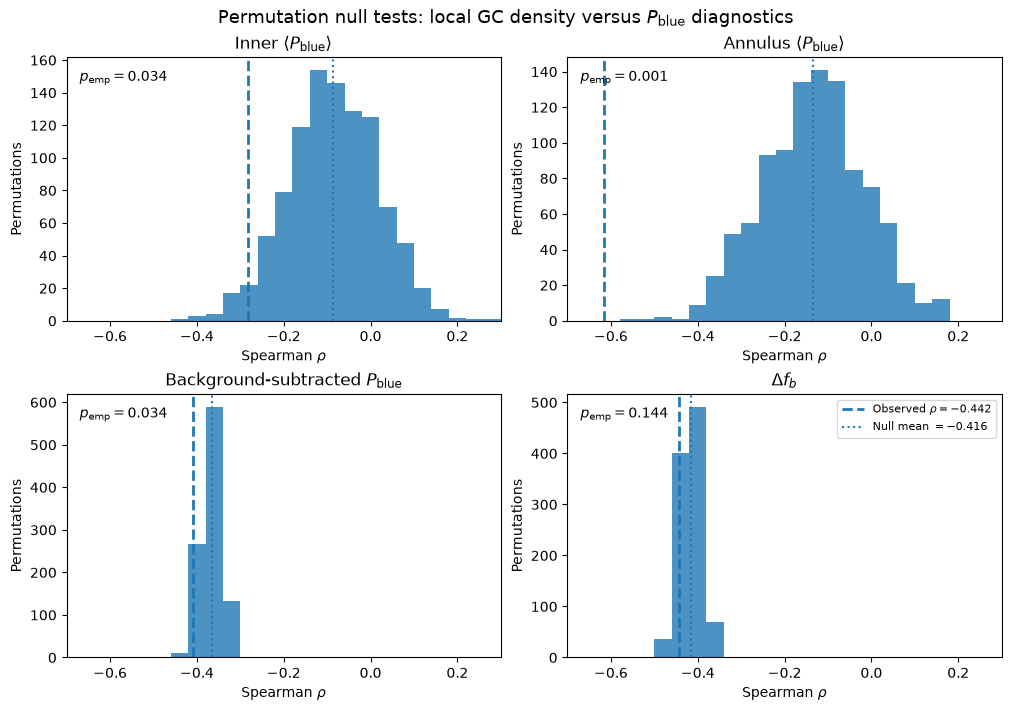

In [71]:
import matplotlib.pyplot as plt
import numpy as np

observed = {
    "rho_inner":   -0.2823,
    "rho_annulus": -0.6167,
    "rho_bgsub":   -0.4084,
    "rho_delta":   -0.4420,
}

labels = {
    "rho_inner":   r"Inner $\langle P_{\rm blue}\rangle$",
    "rho_annulus": r"Annulus $\langle P_{\rm blue}\rangle$",
    "rho_bgsub":   r"Background-subtracted $P_{\rm blue}$",
    "rho_delta":   r"$\Delta f_b$",
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

for ax, col in zip(axes.flat, observed):

    vals = null_df[col].to_numpy()
    rho_obs = observed[col]

    n_extreme = np.sum(vals <= rho_obs)
    p_emp = (n_extreme + 1) / (len(vals) + 1)

    # ax.hist(vals, bins=30, alpha=0.8)
    bins = np.arange(-0.7, 0.31, 0.04)
    ax.hist(vals, bins=bins, alpha=0.8)

    ax.axvline(
        rho_obs,
        linestyle="--",
        linewidth=2,
        label=fr"Observed $\rho={rho_obs:.3f}$"
    )

    ax.axvline(
        np.mean(vals),
        linestyle=":",
        linewidth=1.5,
        label=fr"Null mean $={np.mean(vals):.3f}$"
    )

    ax.set_title(labels[col])
    ax.set_xlabel(r"Spearman $\rho$")
    ax.set_ylabel("Permutations")

    ax.text(
        0.03, 0.95,
        fr"$p_{{\rm emp}}={p_emp:.3f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    xlim = (-0.7, 0.3)
    
    for ax in axes.flat:
        ax.set_xlim(xlim)

    ax.legend(fontsize=8)

fig.suptitle(
    r"Permutation null tests: local GC density versus $P_{\rm blue}$ diagnostics",
    fontsize=13
)

plt.savefig('figures/intermediate/Perm_null_pblue.png', bbox_inches='tight', format='png', dpi=200)

plt.show()

## Figure Interpretation

The purpose of this permutation null experiment has been to ask:

> If there were no real spatial connection between GC colour and environment, how strong a correlation would our analysis pipeline produce anyway?

Each histogram is the answer from 1,000 shuffled versions of the data. The dashed vertical line is what the real data give.

The four panels tell a progression.

- For the inner GC population, the real correlation is more negative than most shuffled versions. That suggests there is probably a genuine environmental signal inside the galaxy apertures. It is not overwhelming, but it is unlikely to be just an artefact of the analysis.

- For the 12–20 $R_e$ annulus, the result is much stronger. The real value lies way beyond essentially all the shuffled realizations. So the annular GC population genuinely changes with environment. This is the clearest result in the figure.

- For the background-subtracted statistic, the shuffled distributions themselves have already become strongly negative. That means the process of subtracting the annulus creates a substantial environmental correlation even when we have randomized the GC colour information. The observed value is somewhat stronger than that null, but not by a huge amount.

- And for the final $\Delta f_b$ statistic, the real value sits comfortably inside the shuffled distribution. That is the crucial result:

The bottom line is that **the strong-looking $\Delta f_b$-density correlation can be reproduced quite easily by the analysis procedure itself.**

BUT...

We are not saying there is no environmental information in the GC populations, because there is, as evident in the *Inner* and very strong nominal background *Annulus* 


# Final environmental cross-check

See if the same 'circularity' as observed in the local-density metric, also manifests in the other environmental measurements.

In [68]:
science = metrics_df[
    np.isfinite(metrics_df["Delta_Pblue_mean_bgsub"])
].copy()

print(f"N science = {len(science)}")

metrics = [
    "Pblue_mean_inner_raw",
    "Pblue_mean_annulus",
]

envs = {
    "Cluster radius": "R_bcg_mid_arcmin",
    "Local density": "gc_bg_voronoi_density_arcsec2_inv",
    "Tidal proxy": "tidal_proxy",
    "Nearest BCG": "R_nearBCG_arcmin",
}

for metric in metrics:
    print(f"\n{metric}")

    for label, env in envs.items():

        sub = science[[metric, env]].dropna()

        rho, p = spearmanr(
            sub[metric],
            sub[env],
        )

        print(
            f"{label:20s} "
            f"rho={rho:+.3f} p={p:.3g}"
        )


N science = 93

Pblue_mean_inner_raw
Cluster radius       rho=+0.166 p=0.111
Local density        rho=-0.282 p=0.00612
Tidal proxy          rho=-0.323 p=0.00161
Nearest BCG          rho=+0.284 p=0.00574

Pblue_mean_annulus
Cluster radius       rho=+0.452 p=5.54e-06
Local density        rho=-0.617 p=4.67e-11
Tidal proxy          rho=-0.507 p=2.1e-07
Nearest BCG          rho=+0.493 p=5.16e-07


## Environmental cross-check. 

The strong signal identified in the nominal 12–20 $R_e$ background annulus is not confined to the local-GC-density estimator. Mean annular $P_{\rm blue}$ correlates strongly with cluster-centric distance ($\rho_s=+0.452$), local GC density ($-0.617$), BCG tidal proxy ($-0.507$), and nearest-BCG distance ($+0.493$), with all four relations highly significant. The corresponding inner-aperture trends have the same signs but are systematically weaker. This demonstrates that the annular population contains coherent environmental information across the Coma core and cannot be treated as an environmentally invariant contaminating background.